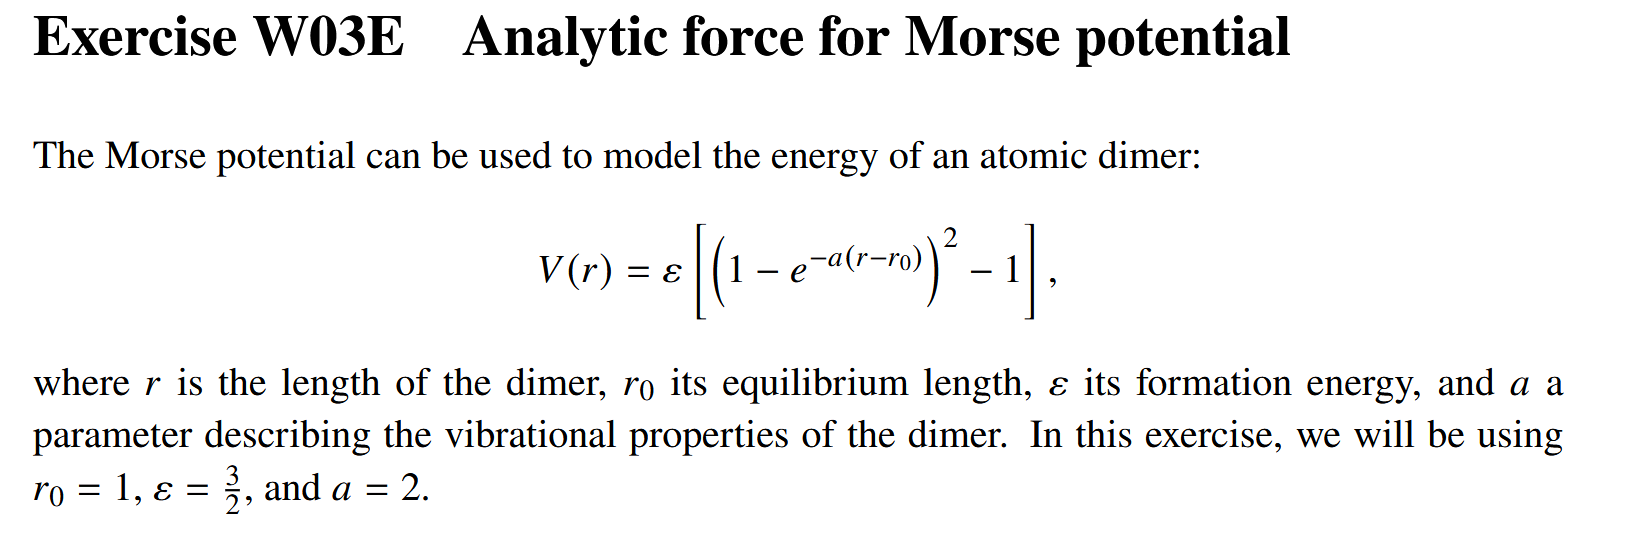

Text(0, 0.5, 'V(r)')

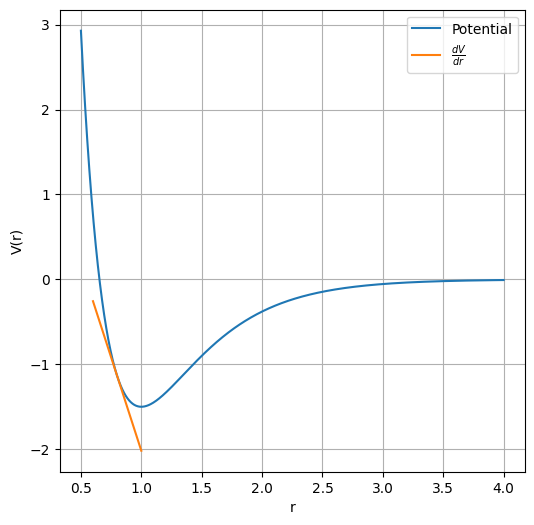

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def V(r, r0=1, ε=3/2, a=2):
    return ε*((1 - np.exp(-a*(r - r0)))**2 - 1)

def dVdr(r, r0=1, ε=3/2, a=2):
    return 2*a*ε*(np.exp(-a*(r-r0)) - np.exp(-2*a*(r-r0)))

def linfunc(x, a, b):
    return a*x + b

fig, ax = plt.subplots(1, 1, figsize=(6,6))
x = np.linspace(0.5, 4.0, 1000)
ax.plot(x, V(x), label='Potential')

rest = 4/5
r = np.linspace(rest-0.2, rest+0.2)
b = V(rest) - dVdr(rest)*rest
ax.plot(r, linfunc(r, dVdr(rest), b), label=r'$\frac{dV}{dr}$')

ax.legend()
ax.grid()
ax.set_xlabel('r')
ax.set_ylabel('V(r)')

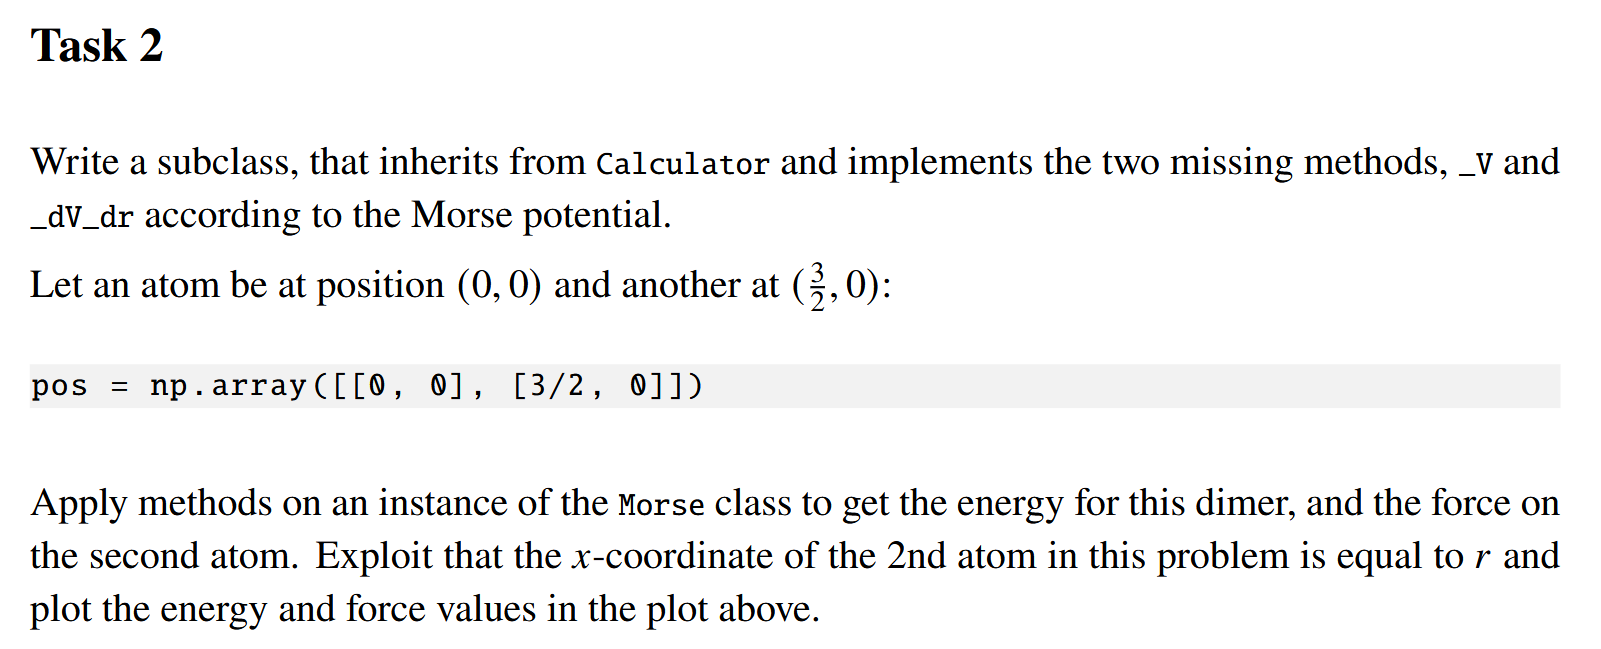

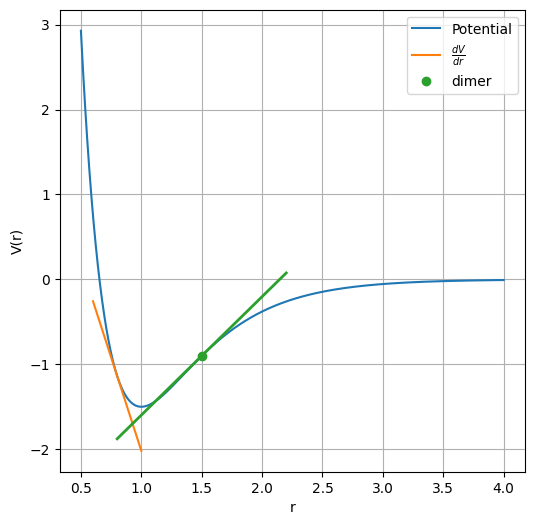

In [2]:
from scipy.spatial.distance import pdist
from week03 import *

class Calculator():
    def potential_energy(self, pos):
        return np.sum(self._V(pdist(pos)))

    def forces(self , pos):
        diff = pos[:, np.newaxis , :] - pos[np.newaxis , :, :]
        r = np.sqrt(np.sum(diff **2, axis =-1))
        np.fill_diagonal(r, np.inf)
        force_magnitude = -self._dV_dr(r)
        forces = np.sum( force_magnitude [... , np. newaxis ] * diff / 
                        r[... , np. newaxis ], axis =1)
        return forces

class Potentials(Calculator):
    def _V(self, r, r0=1, ε=3/2, a=2):
        return ε*((1 - np.exp(-a*(r - r0)))**2 - 1)

    def _dV_dr(self, r, r0=1, ε=3/2, a=2):
        return 2*a*ε*(np.exp(-a*(r-r0)) - np.exp(-2*a*(r-r0)))

pos = np.array([[0, 0], [3/2, 0]])

morse = Potentials()

E = morse.potential_energy(pos)

# forces(pos) returns a matrix of forces for all atoms. 
# We want the x-component of the force on the 2nd atom (index 1).
F = morse.forces(pos)[1, 0]

r_dimer = 3/2

ax.plot(r_dimer, E, 'C2o', label='dimer')
slope = -F
r_tangent = np.linspace(r_dimer - 0.7, r_dimer + 0.7, 10)
V_tangent = slope * (r_tangent - r_dimer) + E 
ax.plot(r_tangent, V_tangent, 'C2', lw=2)

ax.legend()
fig
